# Google TabFM — Zero to Mastery: Regression

**A complete, hands-on tutorial on Google Research's TabFM (Tabular Foundation Model)**, applied
end-to-end to a real regression problem: predicting median house value from the California Housing
census dataset.

This is a standalone companion to the classification tutorial — if you've already worked through
that notebook, the theory in Sections 1–2 will be familiar, but the regression-specific mechanics
(target scaling, no calibration step, different evaluation metrics) are new. If this is the first
TabFM notebook you're opening, everything you need is here.

**Dataset:** California Housing (20,640 rows), downloaded live inside this notebook via
scikit-learn — no bundled files. This is the *exact* dataset Google's own TabArena evaluation used
for one of its 13 regression tasks, which lets us sanity-check our own results against a published
external reference point later on.

**Hardware:** Runs on CPU — see the classification notebook (or Section 3 below) for why we made
that call deliberately rather than defaulting to GPU.

**Estimated runtime:** ~20–30 minutes on a modern laptop CPU, most of it inside the two TabFM
inference cells in Sections 9 and 10.

**License note:** TabFM's *code* is Apache-2.0; the *pretrained weights* are non-commercial-licensed.
This notebook is for learning and evaluation.

---


## 1. What Is a Tabular Foundation Model?

Text and vision foundation models (GPT-style, CLIP-style) work by pretraining once on a huge
generic corpus and reusing the result, zero-shot, on new tasks. Tabular data resisted this for a
structural reason: **a spreadsheet has no shared vocabulary.** A column called `MedInc` in one
dataset and `avg_income` in another don't share a token embedding the way "dog" means the same
thing across English sentences — column semantics, count, order, and scale differ across every
dataset, so a model trained on one schema has no obvious way to transfer to a totally different
one.

**In-context learning (ICL)** sidesteps this: instead of building a shared vocabulary across
arbitrary schemas, an ICL model treats your *entire labeled training set* as a prompt. It reads
your training rows (features **and** targets) as context, then predicts the target for new rows in
a single forward pass — no gradient updates, no per-dataset training. It was pretrained once, on
a huge number of *synthetic* tables, to learn the general skill of "infer the relationship between
features and a target from a table of examples" — a skill that transfers to any new table, because
every dataset supplies its own context.

This lineage started with **TabPFN** and continued with **TabICL** (which scaled ICL to larger
tables by compressing rows before the expensive attention step). Google's **TabFM** combines both
ideas, and — importantly for this notebook — supports **regression on continuous targets**, not
just classification.

**Key definitions for this notebook:**

| Term | Meaning here |
|---|---|
| **Zero-shot inference** | Predicting on a new dataset with no dataset-specific training or hyperparameter search. |
| **In-context learning (ICL)** | The model reads labeled examples as *context* at inference time, instead of updating its weights on them. |
| **"Fitting" a `TabFMRegressor`** | Prepares data encoders and target standardization — it does **not** train the model's weights. |


## 2. Google TabFM: Architecture, Training, and Where It Fits

TabFM comes from **Google Research**, announced via a
[research blog post](https://research.google/blog/introducing-tabfm-a-zero-shot-foundation-model-for-tabular-data/),
an open [GitHub repo](https://github.com/google-research/tabfm), and Hugging Face model cards —
positioned explicitly as the tabular sibling to Google's time-series foundation model, **TimesFM**.

**Architecture** (identical backbone for classification and regression — only the output head and
target handling differ):

1. **Column attention** (TabPFN/Set-Transformer style): Fourier-feature cell embeddings, columns
   attend to each other via induced self-attention.
2. **Row compression** (TabICL style): CLS tokens + Rotary Position Embedding compress each full
   row into one dense vector.
3. **In-context Transformer**: a 24-block causal transformer over the compressed row vectors,
   with training rows as context and test rows as the query. For regression, the target is
   standardized (zero mean, unit variance) before being shown to the model, and predictions are
   inverse-transformed back to the original scale afterwards.

| Hyperparameter | Value |
|---|---|
| Embedding dim | 256 |
| Column-attention blocks | 3 (4 heads, 256 induced points) |
| Row-attention blocks | 3 (8 heads, 8 CLS tokens) |
| ICL transformer blocks | 24 (8 heads) |
| Activation | SwiGLU |
| Optimized table width | up to ~500 features |

**Training data:** entirely **synthetic** — hundreds of millions of tables generated from
structural causal models, chosen specifically to avoid the scarcity and privacy problems of real
tabular data at this scale. No parameter count or compute budget has been publicly disclosed.

**License split:** code is Apache-2.0; the pretrained *weights* ship under a
**"TabFM Non-Commercial License v1.0."** There is also no arXiv paper or technical report as of
this writing — the public record is the blog post, GitHub README, and model cards.

**Evaluation:** Google reports TabFM beating heavily-tuned GBM baselines zero-shot on TabArena's
13 regression tasks, including **California Housing** — the exact dataset we use below, which
means we can compare our own numbers against a published external result at the end of this
notebook.


## 3. Environment Setup

We use **[uv](https://docs.astral.sh/uv/)** to manage this environment — `uv venv --python 3.13.13`
created the virtual environment this kernel runs in. The cell below installs every dependency via
`uv pip install`, targeted at this kernel's interpreter; safe to re-run.

**A real gotcha, worth knowing:** the PyPI package `tabfm==1.0.0` ships a loader that hardcodes a
`pytorch_model.bin` filename, but the Hugging Face repo only contains `model.safetensors` — so the
documented Quick Start raises a bare `FileNotFoundError`. We install from GitHub `main` instead,
which uses the corrected loading path, and add `safetensors` explicitly since `huggingface_hub`
imports it lazily and fails with an unhelpful `NameError` otherwise.


In [1]:
import sys

!uv pip install --python {sys.executable} -q \
    "tabfm[pytorch] @ git+https://github.com/google-research/tabfm.git" \
    safetensors scikit-learn pandas numpy matplotlib seaborn xgboost


In [2]:
import time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

sns.set_theme(style="whitegrid")
print(f"torch {torch.__version__} | cuda available: {torch.cuda.is_available()}")


torch 2.12.1+cu130 | cuda available: True


### A note on device selection

Same reasoning as the classification notebook: GPUs are often shared with other workloads, and
TabFM's own reported benchmarks show a large first-call compilation/download overhead. We only
request CUDA if there's comfortably enough free memory, and we explicitly request `float32` compute
on CPU — we measured `bfloat16` (the model's default) running roughly **4× slower** than `float32`
on CPU with no accuracy benefit for our purposes.


In [3]:
def pick_device(min_free_gb=6.0):
    """Use the GPU only if it looks genuinely free; it may be shared with other processes."""
    if not torch.cuda.is_available():
        return "cpu"
    free_bytes, _ = torch.cuda.mem_get_info()
    free_gb = free_bytes / 1e9
    print(f"GPU free memory: {free_gb:.2f} GB")
    return "cuda" if free_gb >= min_free_gb else "cpu"

DEVICE = pick_device()
COMPUTE_DTYPE = torch.float32
print("Selected device:", DEVICE, "| dtype:", COMPUTE_DTYPE)


GPU free memory: 8.04 GB
Selected device: cuda | dtype: torch.float32


## 4. Loading TabFM

`tabfm_v1_0_0.load(model_type="regression")` loads the regression checkpoint — a separate set of
weights from the classification model, downloaded from the same (ungated, no-login-required)
Hugging Face repo.


In [4]:
from tabfm import TabFMRegressor, tabfm_v1_0_0_pytorch as tabfm_v1_0_0

t0 = time.time()
try:
    tabfm_model = tabfm_v1_0_0.load(model_type="regression", device=DEVICE, dtype=COMPUTE_DTYPE)
except torch.cuda.OutOfMemoryError:
    print("GPU out of memory — falling back to CPU.")
    DEVICE = "cpu"
    tabfm_model = tabfm_v1_0_0.load(model_type="regression", device=DEVICE, dtype=COMPUTE_DTYPE)
print(f"Loaded TabFM regression weights on {DEVICE} in {time.time() - t0:.1f}s")


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights from local directory


Loaded TabFM regression weights on cuda in 9.8s


## 5. Dataset: California Housing

The **California Housing** dataset (20,640 rows, derived from the 1990 US Census) is a classic
regression benchmark: predict median house value for a census block group from eight numeric
features — median income, house age, average rooms/bedrooms, population, average occupancy, and
geographic coordinates. It's fully numeric (no categorical columns, no missing values), which makes
it a clean second example after Adult's mixed-type complexity, and it's real, publicly documented,
and small enough to be tractable end-to-end on a laptop.

We fetch it live via `scikit-learn` (which downloads it from a remote mirror on first use, not from
a bundled file).


In [5]:
from sklearn.datasets import fetch_california_housing

t0 = time.time()
housing = fetch_california_housing(as_frame=True, data_home=".cache_data").frame
print(f"Downloaded California Housing dataset: {housing.shape[0]:,} rows x {housing.shape[1]} columns in {time.time() - t0:.1f}s")
housing.head()


Downloaded California Housing dataset: 20,640 rows x 9 columns in 0.0s


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 6. Exploratory Data Analysis

The target, `MedHouseVal`, is in units of **$100,000**. One real-data quirk worth knowing before
you evaluate anything: the original 1990 Census survey **capped** reported home values at $500,001,
so every block group actually worth more than that is recorded at exactly the same ceiling value.
Let's confirm that ourselves rather than take our word for it.


In [6]:
cap = housing["MedHouseVal"].max()
n_at_cap = (housing["MedHouseVal"] == cap).sum()
print(f"Target max value: {cap} (${cap * 100000:,.0f})")
print(f"Rows pinned at this ceiling: {n_at_cap:,} / {len(housing):,} ({n_at_cap / len(housing):.1%})")
print(f"\nMissing values: {housing.isna().sum().sum()}")


Target max value: 5.00001 ($500,001)
Rows pinned at this ceiling: 965 / 20,640 (4.7%)

Missing values: 0


That's a real censoring artifact affecting nearly 5% of the data — any model, TabFM included, is
structurally unable to predict *above* that ceiling accurately for genuinely more expensive homes,
since the training signal itself is truncated. Worth remembering when interpreting residuals for
the highest-value block groups later in this notebook.


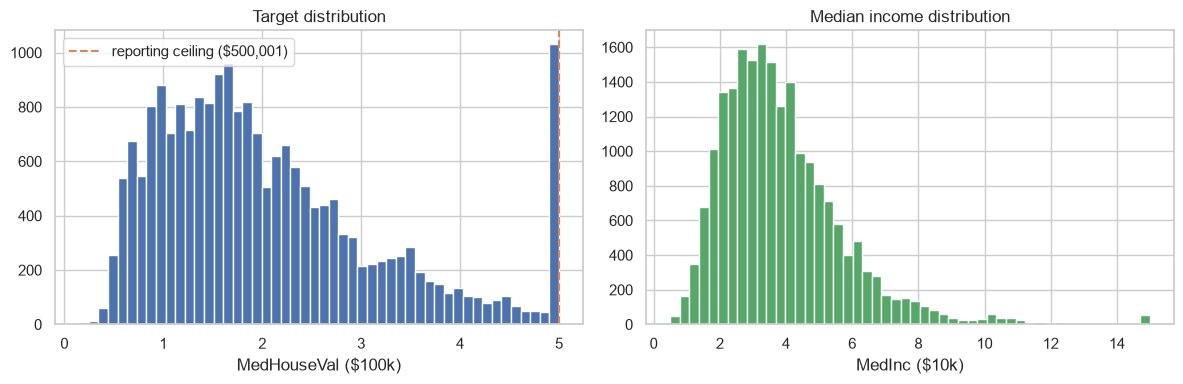

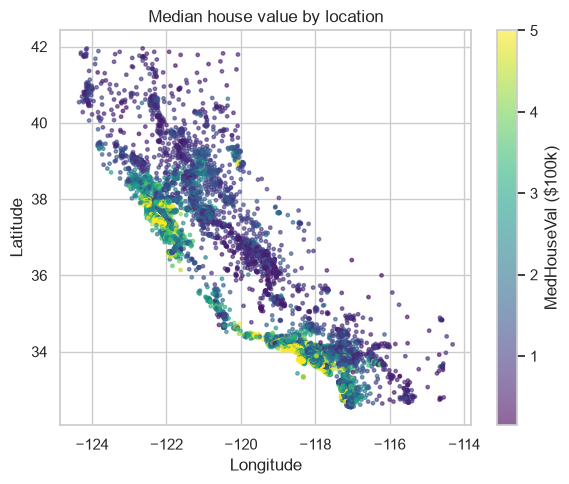

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(housing["MedHouseVal"], bins=50, color="#4C72B0")
axes[0].axvline(cap, color="#DD8452", linestyle="--", label=f"reporting ceiling (${cap * 100000:,.0f})")
axes[0].set_title("Target distribution")
axes[0].set_xlabel("MedHouseVal ($100k)")
axes[0].legend()

axes[1].hist(housing["MedInc"], bins=50, color="#55A868")
axes[1].set_title("Median income distribution")
axes[1].set_xlabel("MedInc ($10k)")

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
sc = plt.scatter(housing["Longitude"], housing["Latitude"], c=housing["MedHouseVal"], cmap="viridis", s=6, alpha=0.6)
plt.colorbar(sc, label="MedHouseVal ($100k)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Median house value by location")
plt.tight_layout()
plt.show()


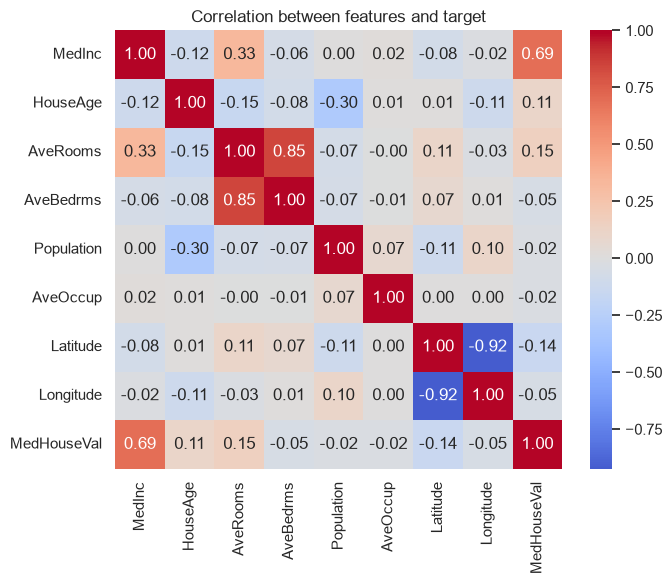

In [8]:
corr = housing.corr()
plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation between features and target")
plt.tight_layout()
plt.show()


## 7. Train/Test Split and the In-Context "Training" Set

As in the classification notebook: `.fit()` on a `TabFMRegressor` does not train the model's
weights — it prepares data encoders and target standardization. The actual "learning" happens
inside the frozen model at prediction time, when it reads your context rows (features **and**
targets this time) alongside the rows you want predictions for.

Cost scales with how many rows you show it as context — worse than linearly, per our own timing in
the classification notebook. Since California Housing is fully numeric and smaller than Adult, we
can afford a slightly larger context here, but we still deliberately subsample rather than handing
TabFM the full ~16,500-row training pool. Our classical baselines, by contrast, train on the full
pool — no context-size penalty for them.


In [9]:
FEATURES = [c for c in housing.columns if c != "MedHouseVal"]
X = housing[FEATURES]
y = housing["MedHouseVal"]

X_train_pool, X_test_pool, y_train_pool, y_test_pool = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train pool: {len(X_train_pool):,} rows | Test pool: {len(X_test_pool):,} rows")


Train pool: 16,512 rows | Test pool: 4,128 rows


In [10]:
N_CONTEXT = 2500   # rows shown to TabFM as in-context "training" examples
N_EVAL = 1000        # rows every model (TabFM included) is scored on


def subsample(X, y, n, seed=42):
    idx = np.random.RandomState(seed).choice(len(X), size=n, replace=False)
    return X.iloc[idx].reset_index(drop=True), y.iloc[idx].reset_index(drop=True)


X_context, y_context = subsample(X_train_pool, y_train_pool, N_CONTEXT)
X_eval, y_eval = subsample(X_test_pool, y_test_pool, N_EVAL)
print(f"Context: {len(X_context):,} rows | Eval: {len(X_eval):,} rows")


Context: 2,500 rows | Eval: 1,000 rows


## 8. Baseline Models

Two classical baselines, both trained on the **full** ~16,500-row training pool:

- **`LinearRegression`** — the simplest possible baseline, no tuning at all.
- **`XGBoost`** — the "well-tuned gradient-boosted tree" TabArena claims TabFM beats. Reasonable
  defaults, not a full hyperparameter search, but a genuinely strong bar.

Both are scored on the same 1,000-row `X_eval` every other model in this notebook uses.


In [11]:
from sklearn.linear_model import LinearRegression
import xgboost as xgb

lin_reg = LinearRegression()
t0 = time.time()
lin_reg.fit(X_train_pool, y_train_pool)
print(f"LinearRegression fit on {len(X_train_pool):,} rows in {time.time() - t0:.1f}s")

xgb_reg = xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1, tree_method="hist", random_state=42)
t0 = time.time()
xgb_reg.fit(X_train_pool, y_train_pool)
print(f"XGBoost fit on {len(X_train_pool):,} rows in {time.time() - t0:.1f}s")


LinearRegression fit on 16,512 rows in 0.0s


XGBoost fit on 16,512 rows in 0.2s


In [12]:
lin_pred = lin_reg.predict(X_eval)
xgb_pred = xgb_reg.predict(X_eval)

results = {}


def score(name, y_true, pred):
    results[name] = {
        "RMSE": mean_squared_error(y_true, pred) ** 0.5,
        "MAE": mean_absolute_error(y_true, pred),
        "R2": r2_score(y_true, pred),
        "MAPE": mean_absolute_percentage_error(y_true, pred),
    }


score("LinearRegression", y_eval, lin_pred)
score("XGBoost", y_eval, xgb_pred)
display(pd.DataFrame(results).T.round(4))


,RMSE,MAE,R2,MAPE
LinearRegression,0.7024,0.5165,0.6108,0.2944
XGBoost,0.4733,0.3040,0.8232,0.1655


## 9. Zero-Shot Regression with TabFM

Same parameter choices as the classification notebook, adapted for regression:

- `n_estimators=8` (Google's default is 32; we scale down for CPU-friendly runtime).
- `batch_size=1` for conservative memory use.
- No `max_num_rows` — we already control context size via `X_context`, and it's incompatible with
  the `.ensemble()` preset used in Section 10.

We fold two synthetic "new house" rows into the same `predict()` call as our evaluation set — since
cost is dominated by context rows, this is essentially free compared to a separate call later.


In [13]:
new_houses = pd.DataFrame([
    {"MedInc": 8.5, "HouseAge": 15.0, "AveRooms": 6.5, "AveBedrms": 1.0, "Population": 1200.0,
     "AveOccup": 2.8, "Latitude": 37.77, "Longitude": -122.42},   # affluent, San Francisco-ish
    {"MedInc": 2.5, "HouseAge": 35.0, "AveRooms": 4.8, "AveBedrms": 1.1, "Population": 900.0,
     "AveOccup": 3.5, "Latitude": 36.75, "Longitude": -119.77},   # lower-income, Central Valley-ish
])
new_houses


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.5,15.0,6.5,1.0,1200.0,2.8,37.77,-122.42
1,2.5,35.0,4.8,1.1,900.0,3.5,36.75,-119.77


In [14]:
X_eval_plus_new = pd.concat([X_eval, new_houses], ignore_index=True)

reg_fast = TabFMRegressor(model=tabfm_model, n_estimators=8, batch_size=1, random_state=42)

t0 = time.time()
reg_fast.fit(X_context, y_context.to_numpy())
pred_fast_all = reg_fast.predict(X_eval_plus_new)
fast_time = time.time() - t0

pred_fast_eval = pred_fast_all[:len(X_eval)]
pred_fast_new = pred_fast_all[len(X_eval):]

print(f"TabFM (fast preset): {len(X_context)} context rows + {len(X_eval_plus_new)} query rows "
      f"-> fit+predict in {fast_time:.1f}s")
score("TabFM (fast)", y_eval, pred_fast_eval)
display(pd.DataFrame(results).T.round(4))


TabFM (fast preset): 2500 context rows + 1002 query rows -> fit+predict in 24.7s


,RMSE,MAE,R2,MAPE
LinearRegression,0.7024,0.5165,0.6108,0.2944
XGBoost,0.4733,0.3040,0.8232,0.1655
TabFM (fast),0.4287,0.2741,0.8550,0.1445


## 10. The Ensemble Preset

`TabFMRegressor.ensemble(model, ...)` configures the same frozen weights with a heavier recipe:
square-root-scheduled feature crosses and SVD features, plus NNLS-weighted blending across ensemble
members (there's no calibration step here — that's classification-only). We override the default
`n_estimators=32` down to `12` for the same CPU-budget reasons as Section 9.

**External sanity check:** Google's own TabArena evaluation, using the *full* dataset and a
different context/ensemble configuration than ours, reported an RMSE of **37,381** for TabFM vs.
**47,254** for XGBoost on this exact dataset (values in raw dollars). Our numbers below use a much
smaller context for CPU runtime and are **not directly comparable** to that published figure — but
we should see the same qualitative pattern (TabFM competitive with or ahead of XGBoost) if the
result is real rather than a benchmark artifact.


In [15]:
reg_ens = TabFMRegressor.ensemble(tabfm_model, n_estimators=12, random_state=42)

t0 = time.time()
reg_ens.fit(X_context, y_context.to_numpy())
pred_ens_all = reg_ens.predict(X_eval_plus_new)
ens_time = time.time() - t0

pred_ens_eval = pred_ens_all[:len(X_eval)]
pred_ens_new = pred_ens_all[len(X_eval):]

print(f"TabFM (ensemble preset): fit+predict in {ens_time:.1f}s "
      f"({ens_time / fast_time:.1f}x the fast preset's wall-clock)")
score("TabFM (ensemble)", y_eval, pred_ens_eval)
display(pd.DataFrame(results).T.round(4))


TabFM (ensemble preset): fit+predict in 177.7s (7.2x the fast preset's wall-clock)


,RMSE,MAE,R2,MAPE
LinearRegression,0.7024,0.5165,0.6108,0.2944
XGBoost,0.4733,0.3040,0.8232,0.1655
TabFM (fast),0.4287,0.2741,0.8550,0.1445
TabFM (ensemble),0.4298,0.2751,0.8542,0.1447


## 11. Residual Analysis

All plots below reuse the predictions we already computed — no new model calls.


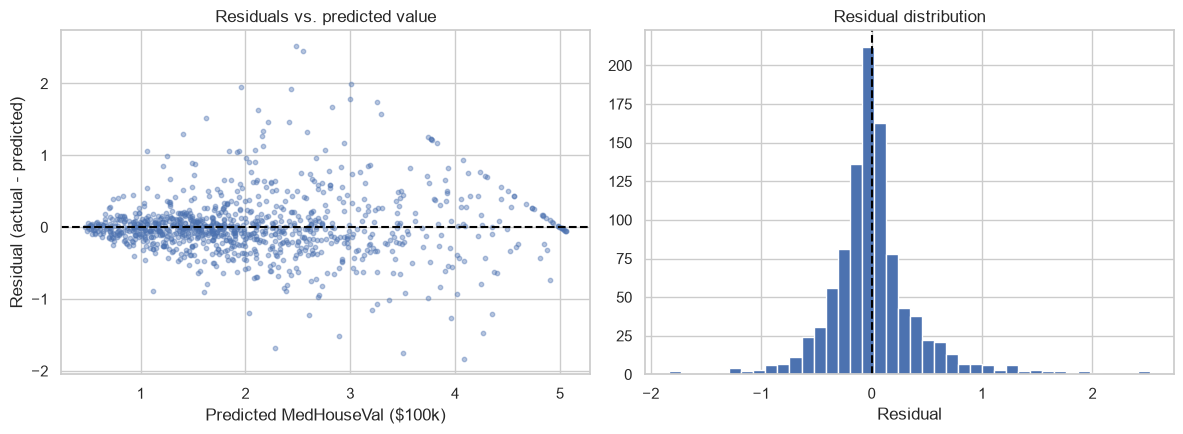

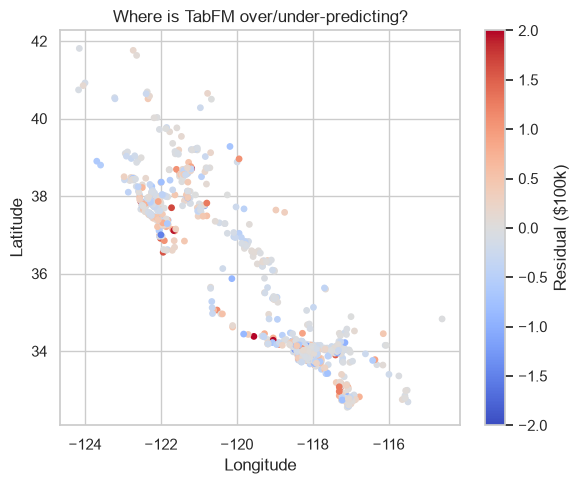

In [16]:
residuals = y_eval.to_numpy() - pred_fast_eval

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(pred_fast_eval, residuals, alpha=0.4, s=10, color="#4C72B0")
axes[0].axhline(0, color="black", linestyle="--")
axes[0].set_xlabel("Predicted MedHouseVal ($100k)")
axes[0].set_ylabel("Residual (actual - predicted)")
axes[0].set_title("Residuals vs. predicted value")

axes[1].hist(residuals, bins=40, color="#4C72B0")
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set_xlabel("Residual")
axes[1].set_title("Residual distribution")

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
sc = plt.scatter(X_eval["Longitude"], X_eval["Latitude"], c=residuals, cmap="coolwarm", s=15, vmin=-2, vmax=2)
plt.colorbar(sc, label="Residual ($100k)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Where is TabFM over/under-predicting?")
plt.tight_layout()
plt.show()


If you see the model under-predicting (large positive residuals — actual higher than predicted) on
the small cluster of block groups sitting exactly at the $500,001 reporting ceiling from Section 6,
that's expected: the model was never shown any signal above that ceiling to learn from, in context
or otherwise.


## 12. Interpreting a Black-Box Foundation Model

TabFM has no per-dataset `.feature_importances_` — it never trains on your dataset, so there's
nothing dataset-specific to inspect. We use **permutation importance** instead: shuffle one
feature's values and measure how much RMSE degrades. Because this needs several fresh `predict()`
calls, we use a much smaller, dedicated context (300 rows) purely for this section.


Micro-eval (300-row context / 100-row eval) baseline RMSE: 0.443  (4.4s total)


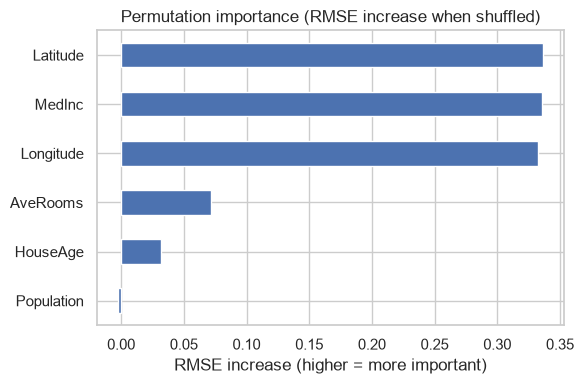

In [17]:
PERM_FEATURES = ["MedInc", "AveRooms", "HouseAge", "Population", "Latitude", "Longitude"]

X_perm_context, y_perm_context = subsample(X_train_pool, y_train_pool, 300, seed=7)
X_perm_eval, y_perm_eval = subsample(X_test_pool, y_test_pool, 100, seed=7)

reg_perm = TabFMRegressor(model=tabfm_model, n_estimators=2, batch_size=1, random_state=42)

t0 = time.time()
reg_perm.fit(X_perm_context, y_perm_context.to_numpy())


def rmse_for(X_):
    p = reg_perm.predict(X_)
    return mean_squared_error(y_perm_eval, p) ** 0.5


base_rmse = rmse_for(X_perm_eval)
importances = {}
rng = np.random.RandomState(0)
for feat in PERM_FEATURES:
    X_shuffled = X_perm_eval.copy()
    X_shuffled[feat] = rng.permutation(X_shuffled[feat].to_numpy())
    importances[feat] = rmse_for(X_shuffled) - base_rmse

print(f"Micro-eval (300-row context / 100-row eval) baseline RMSE: {base_rmse:.3f}  ({time.time() - t0:.1f}s total)")

pd.Series(importances).sort_values().plot(
    kind="barh", figsize=(6, 4), title="Permutation importance (RMSE increase when shuffled)", color="#4C72B0"
)
plt.xlabel("RMSE increase (higher = more important)")
plt.tight_layout()
plt.show()


## 13. Predictions for the New Houses

Back to the two synthetic houses from Section 9 — their predictions came along for free in the
same forward pass as our evaluation set.


In [18]:
for i, row in new_houses.iterrows():
    print(f"House {i + 1}: MedInc={row['MedInc']}, HouseAge={row['HouseAge']}, "
          f"AveRooms={row['AveRooms']}, location=({row['Latitude']}, {row['Longitude']})")
    print(f"  Predicted value -- TabFM (fast): ${pred_fast_new[i] * 100000:,.0f}  |  "
          f"TabFM (ensemble): ${pred_ens_new[i] * 100000:,.0f}")
    print()


House 1: MedInc=8.5, HouseAge=15.0, AveRooms=6.5, location=(37.77, -122.42)
  Predicted value -- TabFM (fast): $440,815  |  TabFM (ensemble): $443,768

House 2: MedInc=2.5, HouseAge=35.0, AveRooms=4.8, location=(36.75, -119.77)
  Predicted value -- TabFM (fast): $60,193  |  TabFM (ensemble): $60,500



## 14. Practical Notes, Gotchas, and When to Reach for TabFM

**What we hit building this notebook (all real, all current as of this writing):**

- `tabfm==1.0.0` on PyPI ships a loader hardcoded to `pytorch_model.bin`; the actual weights are
  `model.safetensors` — install from GitHub `main` instead.
- `safetensors` must be installed explicitly, or `huggingface_hub`'s lazy import fails with a bare
  `NameError`.
- `bfloat16` (the default compute dtype) measured **~4× slower than `float32`** on CPU in our own
  timing — request `float32` explicitly when running on CPU.
- `max_num_rows` and `enable_nnls=True` (set automatically by `.ensemble()`) can't be combined —
  pre-subsample your context yourself instead.

**Documented facts specific to regression (from the model card):**

- The target is standardized internally (`StandardScaler`) and inverse-transformed on output — you
  never need to scale your target yourself.
- There is no calibration step for regression — `binary_calibration_method` /
  `multiclass_calibration_method` are classification-only parameters.
- Same memory-scales-with-context-rows and ~500-feature ceiling as classification.
- Trained entirely on synthetic data; the pretrained weights are non-commercial-licensed.

**What we actually measured, on this exact problem, on CPU:**


In [19]:
timing = pd.DataFrame({
    "wall_clock_s": {
        "TabFM (fast, n_est=8)": fast_time,
        "TabFM (ensemble, n_est=12)": ens_time,
    }
})
display(timing.round(1))
display(pd.DataFrame(results).T.round(4))


,wall_clock_s
"TabFM (fast, n_est=8)",24.7
"TabFM (ensemble, n_est=12)",177.7


,RMSE,MAE,R2,MAPE
LinearRegression,0.7024,0.5165,0.6108,0.2944
XGBoost,0.4733,0.3040,0.8232,0.1655
TabFM (fast),0.4287,0.2741,0.8550,0.1445
TabFM (ensemble),0.4298,0.2751,0.8542,0.1447


**When each approach makes sense:**

- **Reach for TabFM** for a fast, zero-tuning baseline on small-to-medium regression problems,
  especially early in a project when you don't yet know if a heavier model is worth building.
- **Reach for a tuned GBM** for large datasets, latency-sensitive serving, CPU-only production
  infrastructure at scale, or when you need an unrestricted commercial license.
- **Always build your own held-out comparison**, as we did in Sections 8–10, rather than trusting
  a self-reported benchmark number in isolation — context size, hardware, and evaluation
  methodology all change the answer.


## 15. Summary and References

We built a full, real regression pipeline around Google's TabFM: downloaded a production-grade
dataset live, established honest classical baselines, ran zero-shot inference with two TabFM
presets, analyzed residuals (including the dataset's real censoring artifact), interpreted a
black-box in-context model via permutation importance, and made new predictions — while surfacing
the real engineering gotchas involved in actually getting this brand-new model to run.

**References:**

- [Google Research blog: "Introducing TabFM"](https://research.google/blog/introducing-tabfm-a-zero-shot-foundation-model-for-tabular-data/)
- [github.com/google-research/tabfm](https://github.com/google-research/tabfm) — source code (Apache-2.0)
- [huggingface.co/google/tabfm-1.0.0-pytorch](https://huggingface.co/google/tabfm-1.0.0-pytorch) — model card, weights license
- [TabArena benchmark](https://arxiv.org/pdf/2506.16791) — the evaluation suite Google used, including this exact dataset
- [TabPFN-2.5 technical report](https://arxiv.org/abs/2511.08667) — the architectural lineage TabFM builds on
- [California Housing dataset (scikit-learn docs)](https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset)
